<a href="https://colab.research.google.com/github/dbright123/Dbot-Advance1/blob/main/market_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import MetaTrader5 as mt5
import pandas as pd

symbol = "XAUUSD"

def fetch_rates(symbol, timeframe, count=9_000_000):
    """Pull rates from MT5 and return a tidy DataFrame."""
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, count)

    if rates is None:
        raise ValueError(f"MT5 returned None for {symbol}. Error: {mt5.last_error()}")

    df = pd.DataFrame(rates)

    # ── Debug: show what columns MT5 actually gave us ──────────────────────
    print(f"Available columns: {list(df.columns)}")

    # ── Grab volume column whatever it is called ────────────────────────────
    vol_col = next((c for c in df.columns if "volume" in c.lower()), None)
    if vol_col is None:
        raise KeyError(f"No volume column found among: {list(df.columns)}")

    df = df[["time", "open", "high", "low", "close", vol_col]].copy()
    df.rename(columns={vol_col: "volume"}, inplace=True)
    #df["time"] = pd.to_datetime(df["time"], unit="s")
    return df.set_index("time")



def build_multi_tf(symbol):
    if not mt5.initialize("C:\\Program Files\\MetaTrader 5\\terminal64.exe"):
        raise RuntimeError(f"MT5 initialize() failed: {mt5.last_error()}")
    df_5m = fetch_rates(symbol, mt5.TIMEFRAME_M5, 9_000_000).reset_index()
    df_15m = fetch_rates(symbol, mt5.TIMEFRAME_M15, 9_000_000).reset_index()
    df_1h = fetch_rates(symbol, mt5.TIMEFRAME_H1, 9_000_000).reset_index()
    df_4h = fetch_rates(symbol, mt5.TIMEFRAME_H4, 9_000_000).reset_index()
    df_1d = fetch_rates(symbol, mt5.TIMEFRAME_D1, 9_000_000).reset_index()

    def tag_and_shift(df, suffix):
        df = df.sort_values("time").rename(
            columns={c: f"{c}_{suffix}" for c in df.columns if c != "time"})
        val_cols = [c for c in df.columns if c != "time"]
        df[val_cols] = df[val_cols].shift(1)      # only use CLOSED higher-TF bars
        return df
    df_15m = tag_and_shift(df_15m, "15m")
    df_1h = tag_and_shift(df_1h, "1h")
    df_4h = tag_and_shift(df_4h, "4h")
    df_1d = tag_and_shift(df_1d, "1d")
    
    #df_1h = df_1h.sort_values("time")
    df_5m = df_5m.sort_values("time")
    merged = pd.merge_asof(df_5m, df_15m, on="time", direction="backward")
    merged = pd.merge_asof(merged, df_1h, on="time", direction="backward")
    merged = pd.merge_asof(merged, df_4h, on="time", direction="backward")
    #merged = pd.merge_asof(df_1h, df_4h, on="time", direction="backward")
    merged = pd.merge_asof(merged, df_1d, on="time", direction="backward")
    return merged.reset_index(drop=True)
# ── Run ────────────────────────────────────────────────────────────────────────

df = build_multi_tf(symbol)

out_path = f"Generated{symbol} dbot.csv"
df.to_csv(out_path, index=False)
print(f"\nSaved {len(df):,} rows → {out_path}")
print(df.head())

Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
Available columns: ['time', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']

Saved 1,487,388 rows → GeneratedXAUUSD dbot.csv
         time   open   high    low  close  volume  open_15m  high_15m  \
0  1086938100  384.0  384.1  384.0  384.0       3       NaN       NaN   
1  1086938400  384.1  384.1  383.8  383.8       3       NaN       NaN   
2  1086938700  383.8  384.3  383.8  384.3       6       NaN       NaN   
3  1086939000  383.8  383.8  383.8  383.8       2     384.0     384.3   
4  1086939300  383.8  384.3  383.6  383.8       6     384.0     384.3   

   low_15m  

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import warnings

import joblib
from extra_function import RobustPriceLabelerV3, engineer_features, plot_signals,fix_pivot_labels

#warnings.filterwarnings('ignore')

In [3]:
symbol = "XAUUSD"

print("="*70)
print("TRADING SIGNAL CLASSIFICATION SYSTEM")
print("="*70)

# Step 1: Load data from Excel
print("\nStep 1: Loading data from Excel file...")

m_label = "Generated" + symbol






TRADING SIGNAL CLASSIFICATION SYSTEM

Step 1: Loading data from Excel file...


In [39]:
df = pd.read_csv("GeneratedXAUUSD dbot.csv")

In [40]:
# ── Feature engineering ─────────────────────
df = engineer_features(df)   # drop last 200 rows (incomplete bars)

# ── Labelling ───────────────────────────────
labeler = RobustPriceLabelerV3(
    atr_period      = 14,
    zigzag_atr_mult = 5,
    hold_bars       = 5,
    min_streak      = 4,
    target_hold_pct = 5,
)
df = labeler.label(df)

Computing ATR...
Finding zigzag pivots...
   33363 pivots found
Assigning zone labels...
Enforcing class balance...
Computing confidence scores...

── Label Distribution ──────────────────────────
  buy : 608,225  ( 40.9%)  ████████████████
  sell: 552,191  ( 37.1%)  ██████████████
  hold: 326,870  ( 22.0%)  ████████
────────────────────────────────────────────────


In [34]:
df

,open,high,low,close,volume,open_15m,high_15m,low_15m,close_15m,volume_15m,...,close_1d,volume_1d,month,day,hour,minute,day_of_week,label,label_name,label_conf
0,384.30,384.50,384.30,384.30,5,384.10,384.10,384.10,384.10,1.0,...,384.10,303.0,6,14,1,5,0,0,hold,0.332
1,384.30,384.30,384.30,384.30,2,384.30,384.50,384.30,384.30,5.0,...,384.10,303.0,6,14,1,25,0,0,hold,0.332
2,384.30,384.30,384.30,384.30,2,384.30,384.30,384.30,384.30,2.0,...,384.10,303.0,6,14,1,30,0,0,hold,0.332
3,384.30,384.30,384.30,384.30,2,384.30,384.30,384.30,384.30,2.0,...,384.10,303.0,6,14,1,40,0,0,hold,0.332
4,384.30,384.30,384.30,384.30,3,384.30,384.30,384.30,384.30,4.0,...,384.10,303.0,6,14,1,45,0,0,hold,0.346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487281,4356.96,4358.02,4356.22,4357.05,888,4356.76,4358.14,4351.61,4356.96,2626.0,...,4343.88,411745.0,8,10,20,15,0,0,hold,0.365
1487282,4357.11,4360.17,4357.01,4359.88,1236,4356.76,4358.14,4351.61,4356.96,2626.0,...,4343.88,411745.0,8,10,20,20,0,0,hold,0.446
1487283,4359.93,4361.15,4358.48,4361.00,1384,4356.76,4358.14,4351.61,4356.96,2626.0,...,4343.88,411745.0,8,10,20,25,0,0,hold,0.481
1487284,4360.79,4362.59,4359.50,4362.05,1040,4356.96,4361.15,4356.22,4361.00,3508.0,...,4343.88,411745.0,8,10,20,30,0,0,hold,0.400


In [41]:

df_train = df.iloc[:-1000].copy().reset_index(drop=True)
df_test  = df.iloc[-1000:].copy().reset_index(drop=True)
df = df_train
print("train:", df.shape, "| test:", df_test.shape)
print(df[["close","label","label_name","label_conf"]].tail())

train: (1486286, 33) | test: (1000, 33)
           close  label label_name  label_conf
1486281  4080.27      2       sell       0.655
1486282  4080.21      2       sell       0.321
1486283  4080.63      2       sell       0.406
1486284  4080.97      2       sell       0.301
1486285  4081.42      0       hold       0.416


In [44]:


"""Analyze the labeling results"""
print(f"Total samples: {len(df)}")
print(f"Buy labels: {(df['label'] == 1).sum()} ({((df['label'] == 1).sum()/len(df))*100:.1f}%)")
print(f"Sell labels: {(df['label'] == 2).sum()} ({((df['label'] == 2).sum()/len(df))*100:.1f}%)")
print(f"Hold labels: {(df['label'] == 0).sum()} ({((df['label'] == 0).sum()/len(df))*100:.1f}%)")



Total samples: 1486286
Buy labels: 607732 (40.9%)
Sell labels: 551920 (37.1%)
Hold labels: 326634 (22.0%)



Step 5: Visualizing trading signals...


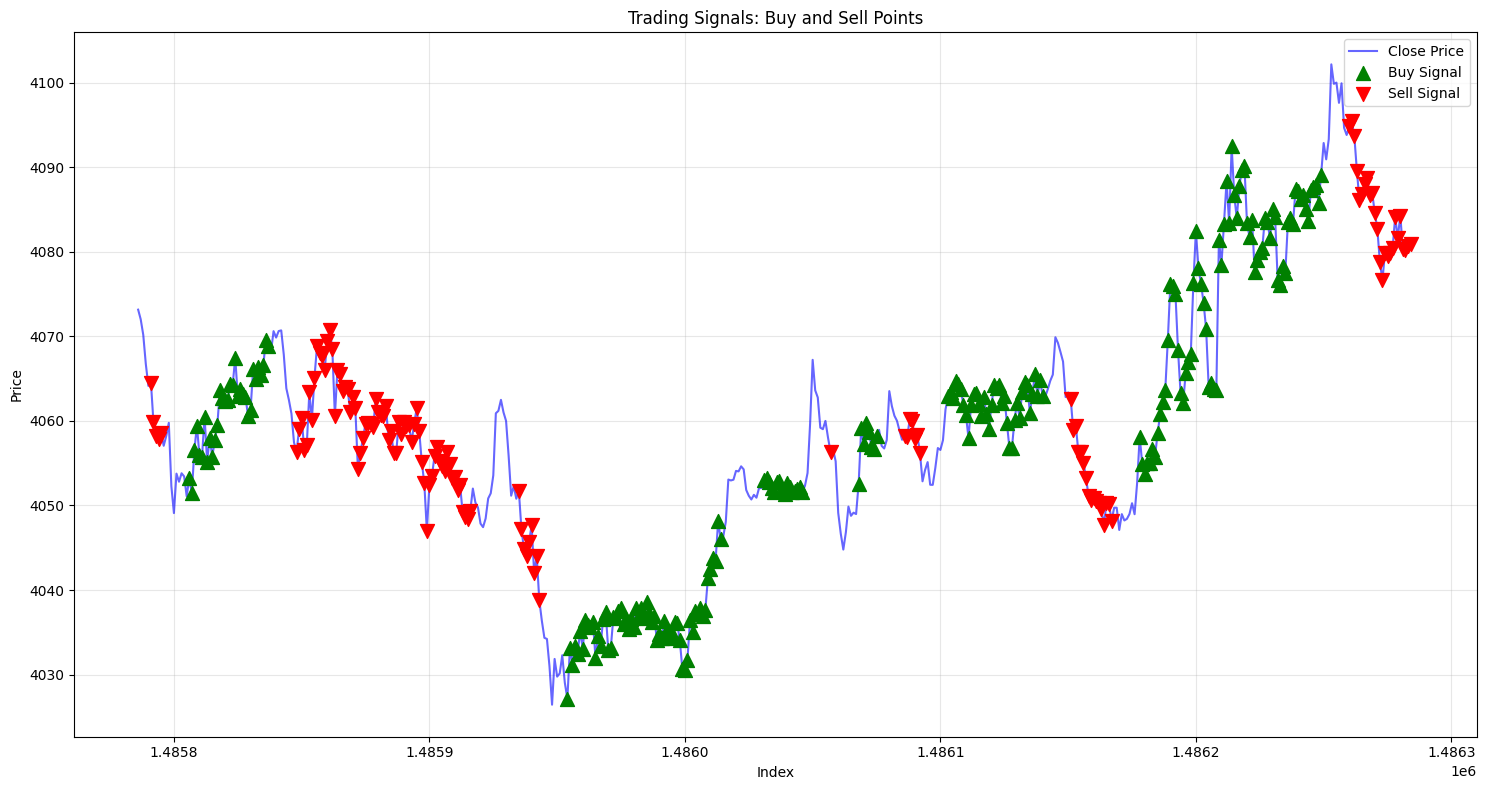


Signal Distribution:
Hold/No Action (0): 140
Buy Signals (1): 227
Sell Signals (2): 133


In [43]:

# Step 5: Visualize signals
print("\nStep 5: Visualizing trading signals...")
plot_signals(df[-500:])



In [30]:
print(f"Data loaded: {len(df)} rows")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Data loaded: 1486286 rows
Memory usage: 420.79 MB


In [11]:
df

,open,high,low,close,volume,open_1h,high_1h,low_1h,close_1h,volume_1h,...,close_1d,volume_1d,month,day,hour,minute,day_of_week,label,label_name,label_conf
0,384.30,384.50,384.30,384.30,5,384.30,384.30,384.10,384.10,3.0,...,384.10,303.0,6,14,1,0,0,0,hold,0.332
1,384.30,384.30,384.30,384.30,2,384.30,384.30,384.10,384.10,3.0,...,384.10,303.0,6,14,1,15,0,0,hold,0.332
2,384.30,384.30,384.30,384.30,4,384.30,384.30,384.10,384.10,3.0,...,384.10,303.0,6,14,1,30,0,0,hold,0.332
3,384.30,384.50,383.60,383.60,5,384.30,384.30,384.10,384.10,3.0,...,384.10,303.0,6,14,1,45,0,0,hold,0.566
4,384.30,384.30,382.60,383.60,21,384.30,384.50,383.60,383.60,16.0,...,384.10,303.0,6,14,2,0,0,0,hold,0.611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507568,4003.35,4008.53,4003.35,4007.39,2135,4004.66,4010.69,3999.70,4000.40,7451.0,...,4006.79,526473.0,7,21,2,30,1,0,hold,0.226
507569,4007.38,4010.37,4004.20,4009.87,3239,4004.66,4010.69,3999.70,4000.40,7451.0,...,4006.79,526473.0,7,21,2,45,1,0,hold,0.294
507570,4009.87,4012.56,4003.48,4010.47,6504,4000.61,4010.37,4000.13,4009.87,10191.0,...,4006.79,526473.0,7,21,3,0,1,0,hold,0.469
507571,4010.45,4018.43,4007.65,4014.88,5505,4000.61,4010.37,4000.13,4009.87,10191.0,...,4006.79,526473.0,7,21,3,15,1,1,buy,0.538


In [12]:
# ── Train / test split ──────────────────────
FEATURE_NAMES = [
    'open', 'high', 'low', 'close', 'volume',
        'open_1h', 'high_1h', 'low_1h', 'close_1h', 'volume_1h',
        'open_4h', 'high_4h', 'low_4h', 'close_4h', 'volume_4h',
        'open_1d', 'high_1d', 'low_1d', 'close_1d', 'volume_1d',
        'hour','minute', 'day', 'month', 'day_of_week',
]
X = df[FEATURE_NAMES].values
y = df['label'].values
#del df

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
print("Before:", y_train.shape)


#del X, y

Before: (456815,)


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=400, 
    random_state=42, 
    class_weight='balanced', 
    verbose=1, 
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("RandomForest Evaluation")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")
print(f"  Classification Report:\n{classification_report(y_test, y_pred_rf)}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed: 11.3min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    2.7s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   13.6s
[Parallel(n_jobs=4)]: Done 400 out of 400 | elapsed:   20.7s finished


RandomForest Evaluation
  Accuracy: 0.9425
  Confusion Matrix:
[[ 9799   744   803]
 [  681 20395     1]
 [  688     4 17643]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87     11346
           1       0.96      0.97      0.97     21077
           2       0.96      0.96      0.96     18335

    accuracy                           0.94     50758
   macro avg       0.93      0.93      0.93     50758
weighted avg       0.94      0.94      0.94     50758



In [14]:
et_model = ExtraTreesClassifier(
    n_estimators=400, 
    class_weight="balanced", 
    random_state=42, 
    n_jobs=-1, 
    verbose=1
)
et_model.fit(X_train, y_train)

y_pred_et = et_model.predict(X_test)

print("\nExtraTrees Evaluation")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_et):.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y_test, y_pred_et)}")
print(f"  Classification Report:\n{classification_report(y_test, y_pred_et)}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   36.3s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:  5.2min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    6.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   27.3s
[Parallel(n_jobs=4)]: Done 400 out of 400 | elapsed:   48.3s finished



ExtraTrees Evaluation
  Accuracy: 0.9479
  Confusion Matrix:
[[ 9986   668   692]
 [  641 20435     1]
 [  643     0 17692]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     11346
           1       0.97      0.97      0.97     21077
           2       0.96      0.96      0.96     18335

    accuracy                           0.95     50758
   macro avg       0.94      0.94      0.94     50758
weighted avg       0.95      0.95      0.95     50758



In [15]:
conditions = [
    (y_pred_rf == 1) & (y_pred_et == 1),
    (y_pred_rf == 2) & (y_pred_et == 2)
]
choices = [1, 2]

y_pred_ensemble = np.select(conditions, choices, default=0)


# ── 4. Evaluate Custom Consensus Ensemble ────────────────────
print("\nConsensus Ensemble Evaluation")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_ensemble):.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y_test, y_pred_ensemble)}")
print(f"  Classification Report:\n{classification_report(y_test, y_pred_ensemble)}")


Consensus Ensemble Evaluation
  Accuracy: 0.9456
  Confusion Matrix:
[[10098   614   634]
 [  761 20315     1]
 [  750     0 17585]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88     11346
           1       0.97      0.96      0.97     21077
           2       0.97      0.96      0.96     18335

    accuracy                           0.95     50758
   macro avg       0.94      0.94      0.94     50758
weighted avg       0.95      0.95      0.95     50758



In [ ]:
#del X_train, y_train

In [36]:
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def predict_and_plot_signals(model, model2, df, feature_columns,
                             ohlc_map=None,
                             chart_style='charles'):
    """
    Predicts buy/sell signals and plots them on an OHLC candlestick chart with an EMA 21.

    Parameters
    ----------
    model : trained classifier with a `predict` method
    df : pandas.DataFrame
        Must contain OHLC columns (default names: 'open','high','low','close')
        and all columns listed in feature_columns.
    feature_columns : list of str
        Columns used as features for the model.
    ohlc_map : dict, optional
        Maps standard OHLC names to actual df column names.
        Default: {'Open':'open','High':'high','Low':'low','Close':'close'}
    chart_style : str, default 'charles'
        mplfinance style (e.g., 'charles', 'yahoo', 'binance', 'default').
    """
    # --- 0. Work on a copy to avoid side effects ---
    data = df.copy()

    # --- 1. Ensure DatetimeIndex ---
    if not pd.api.types.is_datetime64_any_dtype(data.index):
        try:
            data.index = pd.to_datetime(data.index)
        except Exception as e:
            raise ValueError("Could not convert DataFrame index to DatetimeIndex. "
                             "Please provide a DataFrame with a datetime-like index.") from e

    # --- 2. Map OHLC columns ---
    if ohlc_map is None:
        ohlc_map = {'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close'}

    for col in ohlc_map.values():
        if col not in data.columns:
            raise KeyError(f"Required OHLC column '{col}' not found in DataFrame.")

    ohlc_df = data[[ohlc_map['Open'], ohlc_map['High'],
                    ohlc_map['Low'], ohlc_map['Close']]].copy()
    ohlc_df.columns = ['Open', 'High', 'Low', 'Close']
    
    # NEW: Calculate 21-period Exponential Moving Average on the Close price
    ohlc_df['EMA_21'] = ohlc_df['Close'].ewm(span=21, adjust=False).mean()

    # --- 3. Make predictions ---
    X = data[feature_columns].values
    data['predicted_label'] = model.predict(X)
    data['predicted_label2'] = model2.predict(X)

    # --- 4. Build marker Series with the SAME index as ohlc_df ---
    buy_marker = pd.Series(index=ohlc_df.index, dtype=float, name='buy')
    sell_marker = pd.Series(index=ohlc_df.index, dtype=float, name='sell')

    buys = data[(data['predicted_label'] == 1) & (data['predicted_label2'] == 1) & (data['open'] > ohlc_df['EMA_21'])  & (data['close'] > ohlc_df['EMA_21'])]
    if not buys.empty:
        buy_marker.loc[buys.index] = buys[ohlc_map['Low']]

    sells = data[(data['predicted_label'] == 2) & (data['predicted_label2'] == 2) & (data['open'] < ohlc_df['EMA_21'])  & (data['close'] < ohlc_df['EMA_21'])]
    if not sells.empty:
        sell_marker.loc[sells.index] = sells[ohlc_map['High']]

    # --- 5. Create addplots ---
    apds = []
    
    # NEW: Add the EMA plot first so the candlesticks/markers render nicely around it
    apds.append(mpf.make_addplot(ohlc_df['EMA_21'], type='line', color='blue', width=1.5))
    
    if not buys.empty:
        apds.append(mpf.make_addplot(buy_marker, type='scatter', marker='^',
                                     color='green', markersize=100))
    if not sells.empty:
        apds.append(mpf.make_addplot(sell_marker, type='scatter', marker='v',
                                     color='red', markersize=100))

    # --- 6. Plot ---
    fig, axlist = mpf.plot(ohlc_df,
                           type='candle',
                           style=chart_style,
                           title='Market Predictions: Buy/Sell Signals on Candlestick Chart',
                           ylabel='Price',
                           addplot=apds if apds else None,
                           returnfig=True,
                           figsize=(16, 8),
                           volume=False,
                           warn_too_much_data=len(data) + 50)

    # --- 7. Legend (Updated to include EMA 21) ---
    legend_elements = [
        Line2D([0], [0], color='blue', lw=1.5, label='EMA 21'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='green',
               markersize=12, label='Predicted BUY'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor='red',
               markersize=12, label='Predicted SELL')
    ]
    axlist[0].legend(handles=legend_elements, loc='best')
    plt.tight_layout()
    plt.show()

    # --- 8. Print distribution ---
    print("\nSignal Distribution:")
    print(f"Hold / No Action (0): {len(data[data['predicted_label'] == 0])}")
    print(f"Buy Signals      (1): {len(data[data['predicted_label'] == 1])}")
    print(f"Sell Signals     (2): {len(data[data['predicted_label'] == 2])}")
    
    print("\nAgreed Signals (Both Models):")
    print(f"Agreed Buys : {len(buys)}")
    print(f"Agreed Sells: {len(sells)}")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 400 out of 400 | elapsed:    0.4s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 400 out of 400 | elapsed:    0.0s finished
C:\Users\omage\AppData\Local\Temp\ipykernel_10880\2804410943.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


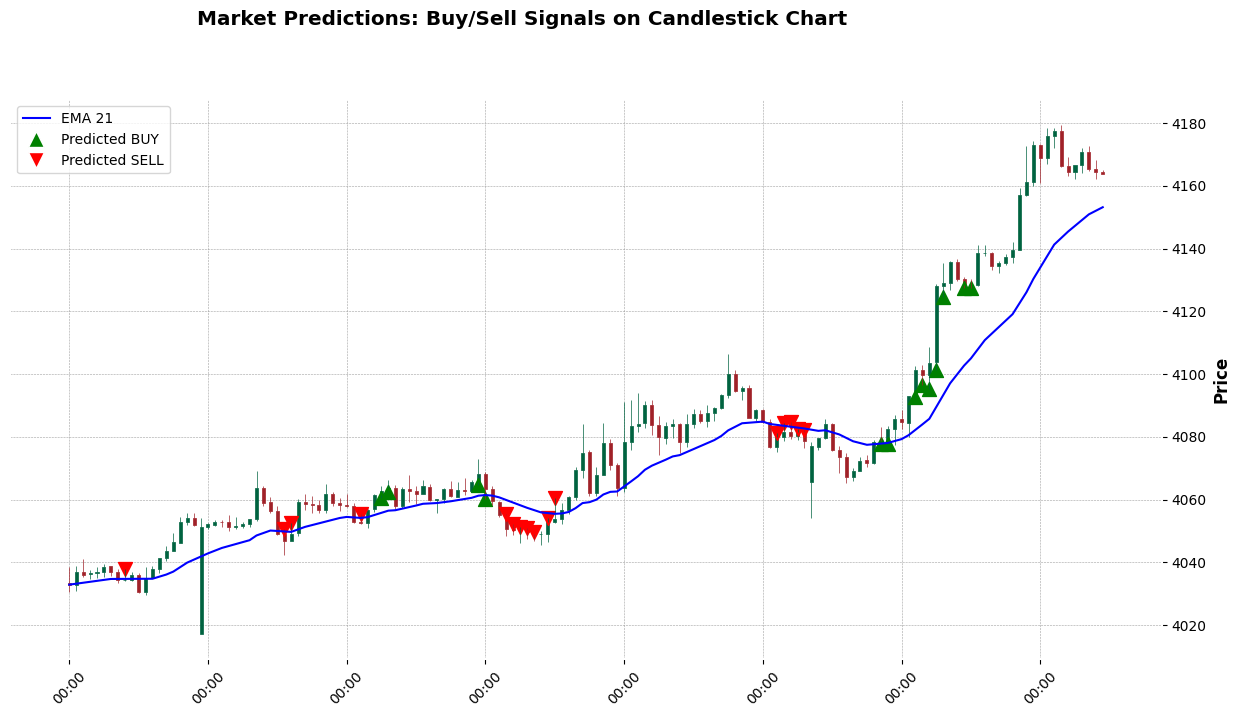


Signal Distribution:
Hold / No Action (0): 9
Buy Signals      (1): 16
Sell Signals     (2): 125

Agreed Signals (Both Models):
Agreed Buys : 13
Agreed Sells: 16


In [37]:

# --- Example Usage ---
# Ensure your 'df' has gone through engineer_features() first
# features = ['open', 'high', 'low', 'volume', 'month', 'day', 'hour', 'minute', 'day_of_week']
#ohlc_map = {'Open':'Open', 'High':'High', 'Low':'Low', 'Close':'Close'}
predict_and_plot_signals(rf_model, et_model, df_test[-150:], FEATURE_NAMES)

# 🧠 LSTM Deep-Learning Pipeline (Time-Series Signal Classification)

This section upgrades the model from a Random-Forest to a **multivariate LSTM** that learns from
sequences of past bars (H1 primary + H4/D1 context + calendar features).

Workflow:
1. **Scale** features (fit on train only — no look-ahead leakage).
2. **Windowing** — build `(samples, lookback, n_features)` sequences for the LSTM.
3. **Class balancing** — `class_weight` (temporal-safe) + optional minority-sequence oversampling for `hold=0 / buy=1 / sell=2`.
4. **GPU hyper-parameter tuning** — Keras-Tuner `Hyperband` searches many architectures/learning-rates.
5. **Evaluation** — confusion matrix + macro-F1 (not just accuracy, which is misleading when imbalanced).
6. **Profit back-test** — verify the signals would actually make money on unseen test data (PnL, win-rate, Sharpe, drawdown).

> Requires: `tensorflow`, `keras-tuner`, `scikit-learn`. Install with:
> `pip install tensorflow keras-tuner scikit-learn`


In [17]:
# ── LSTM: imports & GPU configuration ───────────────────────────────────────
import os
import numpy as np
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view

import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (LSTM, Bidirectional, Dense, Dropout,
                                      BatchNormalization, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
import joblib

# ── GPU setup ───────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)   # don't grab all VRAM at once
    except RuntimeError as e:
        print(e)
print(f"TensorFlow {tf.__version__} | GPUs available: {len(gpus)} -> {gpus}")

# Mixed precision → ~2x faster + less VRAM on modern GPUs (RTX 20xx+/Ampere/Ada).
# Set to False if you see NaNs or use an older/CPU-only setup.
USE_MIXED_PRECISION = len(gpus) > 0
if USE_MIXED_PRECISION:
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled: mixed_float16")

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)



KeyboardInterrupt



In [ ]:
# ── LSTM: scaling + windowing utilities ─────────────────────────────────────
LOOKBACK   = 48          # how many past H1 bars each sequence sees (e.g. 48h = 2 trading days)
N_CLASSES  = 3           # 0=hold, 1=buy, 2=sell

def make_sequences(features: np.ndarray, labels: np.ndarray, lookback: int):
    """
    Turn a (N, F) feature matrix + (N,) label vector into rolling windows.

    Returns
    -------
    X : (N-lookback+1, lookback, F) float32
    y : (N-lookback+1,)            int64
        The label of the LAST bar in each window, so at live time you feed the
        most recent `lookback` bars and predict the signal for the current bar.
    """
    features = np.asarray(features, dtype=np.float32)
    labels   = np.asarray(labels)
    # sliding_window_view -> (N-lookback+1, F, lookback); move time axis before features
    windows = sliding_window_view(features, window_shape=lookback, axis=0)
    windows = windows.transpose(0, 2, 1)          # -> (samples, lookback, F)
    y = labels[lookback - 1:]                     # align to last bar of each window
    return np.ascontiguousarray(windows, dtype=np.float32), y.astype(np.int64)


# ── Fit scaler on TRAIN ONLY (prevents look-ahead leakage) ───────────────────
scaler = RobustScaler()
train_feat = scaler.fit_transform(df_train[FEATURE_NAMES].values.astype(np.float32))
test_feat  = scaler.transform(df_test[FEATURE_NAMES].values.astype(np.float32))

# Persist the scaler so the live trader uses identical scaling
joblib.dump(scaler, "lstm_scaler.joblib")
print("Saved scaler -> lstm_scaler.joblib")

# Build sequences
X_train_full, y_train_full = make_sequences(train_feat, df_train['label'].values, LOOKBACK)
X_test,       y_test       = make_sequences(test_feat,  df_test['label'].values,  LOOKBACK)

# Keep the aligned close prices for the profit back-test later
close_test = df_test['close'].values[LOOKBACK - 1:]

print(f"X_train_full: {X_train_full.shape} | X_test: {X_test.shape}")
print(f"Feature count: {len(FEATURE_NAMES)} | Lookback: {LOOKBACK}")

# ── Temporal train/validation split (NO shuffling — keep chronological order) ──
val_frac   = 0.15
split_idx  = int(len(X_train_full) * (1 - val_frac))
X_tr, y_tr = X_train_full[:split_idx], y_train_full[:split_idx]
X_val, y_val = X_train_full[split_idx:], y_train_full[split_idx:]
print(f"Train: {X_tr.shape} | Val: {X_val.shape}")


Saved scaler -> lstm_scaler.joblib
X_train_full: (127366, 48, 19) | X_test: (953, 48, 19)
Feature count: 19 | Lookback: 48
Train: (108261, 48, 19) | Val: (19105, 48, 19)


In [ ]:
# ── LSTM: class balancing ────────────────────────────────────────────────────
# Strategy:
#   1) class_weight  -> penalises the model more for missing rare classes (temporal-safe).
#   2) OPTIONAL oversampling of minority *sequences* on the TRAIN split only
#      (never on val/test) to give the LSTM more buy/sell examples per epoch.

# 1) Balanced class weights
classes = np.unique(y_tr)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_tr)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weights:", class_weight)

label_map = {0: 'hold', 1: 'buy', 2: 'sell'}
print("Train label distribution:")
for c in classes:
    n = int((y_tr == c).sum())
    print(f"  {label_map[c]:>4} ({c}): {n:>7,}  ({n/len(y_tr)*100:5.2f}%)")

# 2) Optional oversampling (replicate minority sequences up to the majority count)
OVERSAMPLE = True
if OVERSAMPLE:
    counts   = {int(c): int((y_tr == c).sum()) for c in classes}
    max_n    = max(counts.values())
    idx_parts = []
    rng = np.random.default_rng(SEED)
    for c in classes:
        idx_c = np.where(y_tr == c)[0]
        if len(idx_c) < max_n:                       # draw extra samples with replacement
            extra = rng.choice(idx_c, size=max_n - len(idx_c), replace=True)
            idx_c = np.concatenate([idx_c, extra])
        idx_parts.append(idx_c)
    bal_idx = np.concatenate(idx_parts)
    rng.shuffle(bal_idx)                              # mix classes so batches are heterogeneous
    X_tr_bal, y_tr_bal = X_tr[bal_idx], y_tr[bal_idx]
    print(f"\nAfter oversampling: {X_tr_bal.shape} "
          f"(was {X_tr.shape[0]:,} -> {X_tr_bal.shape[0]:,} sequences)")
else:
    X_tr_bal, y_tr_bal = X_tr, y_tr


Class weights: {0: 0.9754034110873855, 1: 0.9871163630395536, 2: 1.0397913905376592}
Train label distribution:
  hold (0):  36,997  (34.17%)
   buy (1):  36,558  (33.77%)
  sell (2):  34,706  (32.06%)

After oversampling: (110991, 48, 19) (was 108,261 -> 110,991 sequences)


In [ ]:
# ── LSTM: GPU hyper-parameter tuning with Keras-Tuner (Hyperband) ────────────
import keras_tuner as kt

INPUT_SHAPE = (LOOKBACK, len(FEATURE_NAMES))

def build_model(hp):
    """Hypermodel: the tuner picks depth, width, dropout, LR, bidirectionality."""
    model = Sequential(name="lstm_signal_clf")
    model.add(Input(shape=INPUT_SHAPE))

    n_layers      = hp.Int("n_lstm_layers", 1, 3)
    bidirectional = hp.Boolean("bidirectional")

    for i in range(n_layers):
        units        = hp.Int(f"units_{i}", min_value=32, max_value=256, step=32)
        return_seq   = i < n_layers - 1                 # only last LSTM returns a vector
        lstm_layer   = LSTM(units, return_sequences=return_seq,
                            recurrent_dropout=0.0)       # 0 recurrent_dropout keeps cuDNN GPU kernel
        model.add(Bidirectional(lstm_layer) if bidirectional else lstm_layer)
        if hp.Boolean(f"batchnorm_{i}"):
            model.add(BatchNormalization())
        model.add(Dropout(hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1)))

    # Dense head
    dense_units = hp.Int("dense_units", 16, 128, step=16)
    model.add(Dense(dense_units, activation="relu"))
    model.add(Dropout(hp.Float("dense_dropout", 0.0, 0.5, step=0.1)))
    # float32 output is required when mixed precision is on
    model.add(Dense(N_CLASSES, activation="softmax", dtype="float32"))

    lr = hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


tuner = kt.Hyperband(
    build_model,
    objective="val_accuracy",
    max_epochs=40,
    factor=3,
    hyperband_iterations=10,          # increase for an even more exhaustive GPU search
    directory="kt_lstm_tuning",
    project_name=f"lstm_XAUUSD",
    overwrite=True,
    seed=SEED,
)
tuner.search_space_summary()

search_callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=6, mode="max",
                  restore_best_weights=True),
]

BATCH_SIZE = 256
tuner.search(
    X_tr_bal, y_tr_bal,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,       # extra safety even with oversampling
    callbacks=search_callbacks,
    verbose=1,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("\nBest hyper-parameters:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")


Trial 2 Complete [00h 00m 32s]
val_accuracy: 0.31337347626686096

Best val_accuracy So Far: 0.3214341700077057
Total elapsed time: 00h 00m 49s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
2                 |2                 |n_lstm_layers
True              |False             |bidirectional
128               |128               |units_0
False             |False             |batchnorm_0
0.2               |0.4               |dropout_0
16                |48                |dense_units
0                 |0.2               |dense_dropout
0.0030433         |0.00013607        |learning_rate
192               |32                |units_1
True              |False             |batchnorm_1
0.1               |0                 |dropout_1
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
3                 |3                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2
434/434 ━

KeyboardInterrupt: 

In [ ]:
# ── LSTM: train the best model to convergence ────────────────────────────────
MODEL_PATH = f"lstm_signal_{symbol}".replace(" ", "_") + ".keras"

model = tuner.hypermodel.build(best_hp)
model.summary()

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=12, mode="max",
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor="val_accuracy", mode="max",
                    save_best_only=True, verbose=1),
]

history = model.fit(
    X_tr_bal, y_tr_bal,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

model.save(MODEL_PATH)
print(f"\nSaved best model -> {MODEL_PATH}")

# ── Learning curves ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(history.history["loss"], label="train")
ax[0].plot(history.history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(history.history["accuracy"], label="train")
ax[1].plot(history.history["val_accuracy"], label="val")
ax[1].set_title("Accuracy"); ax[1].legend()
plt.tight_layout(); plt.show()


In [ ]:
# ── LSTM: classification evaluation on unseen test set ───────────────────────
proba   = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
y_pred  = proba.argmax(axis=1)

acc      = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Test accuracy : {acc:.4f}")
print(f"Test macro-F1 : {macro_f1:.4f}   (better metric for imbalanced classes)")
print("\nConfusion matrix (rows=true, cols=pred) [hold, buy, sell]:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["hold", "buy", "sell"]))


In [ ]:
# ── LSTM: PROFIT back-test — does the model actually make money? ─────────────
# Translates predictions into positions and simulates PnL on the unseen test set.
#   buy(1)  -> long  (+1)
#   sell(2) -> short (-1)
#   hold(0) -> flat  ( 0)
# A position opened on bar t earns the return from bar t -> t+1. A cost is charged
# whenever the position changes (spread/commission), so this is not over-optimistic.

def backtest_signals(preds, close, proba=None, conf_threshold=0.0,
                     cost_pct=0.0002, bars_per_year=24 * 252):
    """
    Parameters
    ----------
    preds : (N,) predicted classes (0/1/2)
    close : (N,) close price aligned to preds
    proba : (N, 3) class probabilities (optional, for confidence filtering)
    conf_threshold : only take trades whose winning-class prob >= threshold
    cost_pct : round-trip transaction cost as a fraction of price (e.g. 0.0002 = 2 bps)
    """
    preds = np.asarray(preds).copy()
    close = np.asarray(close, dtype=np.float64)

    # Confidence filter -> low-confidence predictions become 'hold'
    if proba is not None and conf_threshold > 0:
        max_conf = proba.max(axis=1)
        preds[max_conf < conf_threshold] = 0

    position = np.where(preds == 1, 1.0, np.where(preds == 2, -1.0, 0.0))
    bar_ret  = np.diff(close) / close[:-1]                 # return from t -> t+1
    strat_ret = position[:-1] * bar_ret                    # held into next bar

    # Transaction cost when the position changes
    pos_change = np.abs(np.diff(np.concatenate([[0.0], position[:-1]])))
    strat_ret = strat_ret - pos_change * cost_pct

    equity = np.cumprod(1.0 + strat_ret)
    total_return = equity[-1] - 1.0

    traded = strat_ret[position[:-1] != 0]
    win_rate = (traded > 0).mean() if len(traded) else 0.0
    n_trades = int((pos_change > 0).sum())

    sharpe = (strat_ret.mean() / (strat_ret.std() + 1e-12)) * np.sqrt(bars_per_year)
    running_max = np.maximum.accumulate(equity)
    max_dd = ((equity - running_max) / running_max).min()

    # Buy & hold benchmark
    bh_equity = np.cumprod(1.0 + bar_ret)
    bh_return = bh_equity[-1] - 1.0

    return {
        "total_return_pct": total_return * 100,
        "buy_hold_pct":     bh_return * 100,
        "win_rate_pct":     win_rate * 100,
        "n_trades":         n_trades,
        "sharpe":           sharpe,
        "max_drawdown_pct": max_dd * 100,
        "equity":           equity,
        "bh_equity":        bh_equity,
    }




In [ ]:
# ── Run the base back-test ───────────────────────────────────────────────────
res = backtest_signals(y_pred, close_test, proba=proba, conf_threshold=0.0)
print("── LSTM strategy on unseen test set ─────────────────────────")
print(f"  Total return : {res['total_return_pct']:+.2f}%")
print(f"  Buy & hold   : {res['buy_hold_pct']:+.2f}%")
print(f"  Win rate     : {res['win_rate_pct']:.2f}%")
print(f"  # trades     : {res['n_trades']}")
print(f"  Sharpe       : {res['sharpe']:.2f}")
print(f"  Max drawdown : {res['max_drawdown_pct']:.2f}%")

# ── Sweep confidence threshold to maximise risk-adjusted profit ──────────────
print("\n── Confidence-threshold sweep (find the most profitable cut-off) ──")
print(f"{'thresh':>7} {'return%':>9} {'winrate%':>9} {'trades':>7} {'sharpe':>7} {'maxDD%':>8}")
best = None
for thr in [0.0, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    r = backtest_signals(y_pred, close_test, proba=proba, conf_threshold=thr)
    print(f"{thr:>7.2f} {r['total_return_pct']:>9.2f} {r['win_rate_pct']:>9.2f} "
          f"{r['n_trades']:>7d} {r['sharpe']:>7.2f} {r['max_drawdown_pct']:>8.2f}")
    if r["n_trades"] >= 10 and (best is None or r["sharpe"] > best[1]["sharpe"]):
        best = (thr, r)

if best:
    print(f"\nBest threshold by Sharpe: {best[0]:.2f} "
          f"(return {best[1]['total_return_pct']:+.2f}%, sharpe {best[1]['sharpe']:.2f})")

# ── Equity curve ─────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(res["equity"],    label="LSTM strategy")
plt.plot(res["bh_equity"], label="Buy & hold", alpha=0.7)
plt.axhline(1.0, color="gray", ls="--", lw=0.8)
plt.title(f"Equity curve on unseen test set — {symbol}")
plt.xlabel("Bar"); plt.ylabel("Equity (×)"); plt.legend()
plt.tight_layout(); plt.show()


In [ ]:
# ── LSTM: live inference helper (for the real trader) ────────────────────────
# Feed the most recent bars (already run through engineer_features + multi-TF merge)
# and get the signal for the latest bar. Uses the SAME scaler saved during training.

def predict_latest_signal(recent_df, model, scaler, feature_names=FEATURE_NAMES,
                          lookback=LOOKBACK, conf_threshold=0.6):
    """
    recent_df : DataFrame with at least `lookback` rows and all `feature_names` columns,
                ordered oldest -> newest.
    Returns (signal_int, signal_name, confidence, prob_vector).
    """
    if len(recent_df) < lookback:
        raise ValueError(f"Need >= {lookback} rows, got {len(recent_df)}")

    window = recent_df[feature_names].values[-lookback:].astype(np.float32)
    window = scaler.transform(window)
    window = window.reshape(1, lookback, len(feature_names))

    prob   = model.predict(window, verbose=0)[0]
    signal = int(prob.argmax())
    conf   = float(prob.max())
    if conf < conf_threshold:            # not confident enough -> stay flat
        signal = 0
    return signal, {0: "hold", 1: "buy", 2: "sell"}[signal], conf, prob


# Example on the tail of the test data:
sig, name, conf, prob = predict_latest_signal(df_test, model, scaler)
print(f"Latest signal: {name.upper()} (class {sig}) | confidence {conf:.2%}")
print(f"Probabilities -> hold: {prob[0]:.2%}  buy: {prob[1]:.2%}  sell: {prob[2]:.2%}")

# To reload later in your live trader:
#   model  = load_model("lstm_signal_<symbol>.keras")
#   scaler = joblib.load("lstm_scaler.joblib")


# 🤖 Reinforcement Learning (DQN) Trading Agent — GPU-saturating

Instead of predicting fixed labels, the agent **learns a trading policy** by trial-and-error:
it observes a window of bars + its current position, chooses an action
(**flat / long / short**) and is rewarded by the resulting PnL minus costs.

### Why the Keras-Tuner run felt slow & val-accuracy was poor
- **Hyperband was doing hundreds of fits** (`hyperband_iterations=2`, `max_epochs=40`). Drop to `1` iteration / `~20` epochs for a first pass.
- **Non-stationary features are the real accuracy killer.** Raw OHLC *price levels* drift over time, so the test set sits outside the train scaler's range. Prefer **log-returns / price-relative** features (see tip at the end). This usually matters more than the architecture.
- **Single T4 GPU** → "use all hardware" means: big batches, **XLA JIT**, **mixed precision**, and **vectorized parallel environments** so every GPU forward pass is large.

### This section
1. Enable XLA + threading + confirm GPU.
2. Vectorized trading environment (`N_ENVS` episodes in parallel → large GPU batches).
3. DQN agent (LSTM Q-network, target net, replay buffer — memory-efficient, stores indices).
4. Training loop with a compiled `tf.function` step.
5. Evaluate the learned policy with the same profit back-test.


In [ ]:
# ── RL: performance config + data prep ───────────────────────────────────────
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import mixed_precision

# Saturate the GPU: XLA fuses ops -> big speedup; let TF auto-tune CPU threads.
tf.config.optimizer.set_jit(True)
tf.config.threading.set_intra_op_parallelism_threads(0)   # 0 = auto (all cores)
tf.config.threading.set_inter_op_parallelism_threads(0)
print("XLA JIT enabled:", tf.config.optimizer.get_jit())
print("GPUs:", tf.config.list_physical_devices('GPU'))

USE_MIXED_PRECISION = mixed_precision.global_policy().name == "mixed_float16"
print("Mixed precision:", USE_MIXED_PRECISION)

# States = the exact windows built for the LSTM (already scaled, no leakage).
# Prices aligned to the LAST bar of each window (that is what the agent trades on).
RL_STATES_TRAIN = X_train_full                                  # (N, LOOKBACK, F) float32
RL_PRICES_TRAIN = df_train['close'].values[LOOKBACK - 1:].astype(np.float64)
RL_STATES_TEST  = X_test
RL_PRICES_TEST  = close_test.astype(np.float64)

assert len(RL_STATES_TRAIN) == len(RL_PRICES_TRAIN)
assert len(RL_STATES_TEST)  == len(RL_PRICES_TEST)

SEQ_SHAPE  = (LOOKBACK, len(FEATURE_NAMES))
N_ACTIONS  = 3                                    # 0=flat, 1=long, 2=short
ACTION_TO_POS = np.array([0.0, 1.0, -1.0], dtype=np.float32)
print(f"Train states: {RL_STATES_TRAIN.shape} | Test states: {RL_STATES_TEST.shape}")


XLA JIT enabled: autoclustering
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: True
Train states: (127366, 48, 19) | Test states: (953, 48, 19)


In [ ]:
# ── RL: vectorized environment + replay buffer ───────────────────────────────
class VectorTradingEnv:
    """Runs `n_envs` trading episodes in parallel so each GPU batch is large.
    Reward = new_position * next-bar-return - cost * |position change|."""
    def __init__(self, prices, n_envs, horizon, cost_pct=0.0002):
        self.prices  = prices
        self.N       = len(prices)
        self.n_envs  = n_envs
        self.horizon = horizon
        self.cost    = cost_pct
        self.reset()

    def _rand_starts(self, k):
        return np.random.randint(0, self.N - self.horizon - 1, size=k)

    def reset(self):
        self.t     = self._rand_starts(self.n_envs)
        self.pos   = np.zeros(self.n_envs, dtype=np.float32)
        self.steps = np.zeros(self.n_envs, dtype=np.int32)

    def step(self, actions):
        new_pos = ACTION_TO_POS[actions]
        ret     = (self.prices[self.t + 1] - self.prices[self.t]) / self.prices[self.t]
        reward  = (new_pos * ret - self.cost * np.abs(new_pos - self.pos)).astype(np.float32)

        self.t     = self.t + 1
        self.pos   = new_pos
        self.steps = self.steps + 1
        done       = (self.steps >= self.horizon)

        next_t, next_pos = self.t.copy(), self.pos.copy()   # captured before reset (masked when done)
        if done.any():
            idx = np.where(done)[0]
            self.t[idx]     = self._rand_starts(len(idx))
            self.pos[idx]   = 0.0
            self.steps[idx] = 0
        return reward, next_t, next_pos, done.astype(np.float32)


class ReplayBuffer:
    """Memory-efficient: stores STATE INDICES (not the full windows)."""
    def __init__(self, capacity):
        self.capacity = capacity
        self.t        = np.zeros(capacity, dtype=np.int32)
        self.pos      = np.zeros(capacity, dtype=np.float32)
        self.action   = np.zeros(capacity, dtype=np.int32)
        self.reward   = np.zeros(capacity, dtype=np.float32)
        self.next_t   = np.zeros(capacity, dtype=np.int32)
        self.next_pos = np.zeros(capacity, dtype=np.float32)
        self.done     = np.zeros(capacity, dtype=np.float32)
        self.ptr = 0
        self.size = 0

    def add_batch(self, t, pos, action, reward, next_t, next_pos, done):
        n   = len(t)
        idx = (self.ptr + np.arange(n)) % self.capacity
        self.t[idx], self.pos[idx]         = t, pos
        self.action[idx], self.reward[idx] = action, reward
        self.next_t[idx], self.next_pos[idx] = next_t, next_pos
        self.done[idx] = done
        self.ptr  = (self.ptr + n) % self.capacity
        self.size = min(self.size + n, self.capacity)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (self.t[idx], self.pos[idx], self.action[idx], self.reward[idx],
                self.next_t[idx], self.next_pos[idx], self.done[idx])


def build_q_network(seq_shape, n_actions):
    seq_in = Input(shape=seq_shape, name="window")
    pos_in = Input(shape=(1,), name="position")
    x = LSTM(64)(seq_in)                       # compact LSTM keeps the cuDNN GPU kernel fast
    x = Concatenate()([x, pos_in])
    x = Dense(64, activation="relu")(x)
    x = Dense(32, activation="relu")(x)
    q = Dense(n_actions, activation="linear", dtype="float32", name="q")(x)  # float32 for mixed precision
    return Model([seq_in, pos_in], q, name="dqn_q_network")

print("Environment + replay buffer + Q-network ready.")


Environment + replay buffer + Q-network ready.


In [ ]:
# ── RL: DQN training loop (GPU-saturating, XLA-compiled step) ─────────────────
import time

# ── Hyper-parameters (scale N_ENVS / BATCH up to fill your 15 GB GPU) ─────────
GAMMA         = 0.99
LR            = 1e-3
N_ENVS        = 512          # parallel episodes -> large GPU forward batches
HORIZON       = 256          # bars per episode
BUFFER_SIZE   = 300_000
BATCH_SIZE    = 2048         # big batch -> better GPU utilization
WARMUP        = 10_000       # random steps before learning
TOTAL_STEPS   = 20_000       # env steps (each steps ALL N_ENVS at once)
TARGET_UPDATE = 1_000        # steps between target-net syncs
EPS_START, EPS_END, EPS_DECAY_STEPS = 1.0, 0.05, 12_000
GRAD_CLIP     = 10.0

env    = VectorTradingEnv(RL_PRICES_TRAIN, N_ENVS, HORIZON, cost_pct=0.0002)
buffer = ReplayBuffer(BUFFER_SIZE)

online_net = build_q_network(SEQ_SHAPE, N_ACTIONS)
target_net = build_q_network(SEQ_SHAPE, N_ACTIONS)
target_net.set_weights(online_net.get_weights())

base_opt  = Adam(learning_rate=LR, clipnorm=GRAD_CLIP)
optimizer = mixed_precision.LossScaleOptimizer(base_opt) if USE_MIXED_PRECISION else base_opt
huber     = tf.keras.losses.Huber()

states_train_tf = tf.constant(RL_STATES_TRAIN)   # keep windows on device for fast gather

@tf.function(jit_compile=True)
def gather_states(idx):
    return tf.gather(states_train_tf, idx)

@tf.function
def train_step(s, p, a, r, ns, np_, d):
    next_q     = target_net([ns, np_], training=False)
    max_next_q = tf.reduce_max(next_q, axis=1)
    target     = r + GAMMA * max_next_q * (1.0 - d)
    with tf.GradientTape() as tape:
        q    = online_net([s, p], training=True)
        q_sa = tf.reduce_sum(q * tf.one_hot(a, N_ACTIONS), axis=1)
        loss = huber(tf.stop_gradient(target), q_sa)
        # Keras 3 mixed-precision API: scale the loss; apply_gradients auto-unscales.
        loss_to_min = optimizer.scale_loss(loss) if USE_MIXED_PRECISION else loss
    grads = tape.gradient(loss_to_min, online_net.trainable_variables)
    optimizer.apply_gradients(zip(grads, online_net.trainable_variables))
    return loss

def act_epsilon_greedy(t_idx, pos, epsilon):
    # Keras 3 forbids mixing tf.Tensor + numpy in one call() -> make BOTH tensors.
    s = gather_states(tf.constant(t_idx))
    p = tf.constant(np.asarray(pos, dtype=np.float32)[:, None])
    q = online_net([s, p], training=False).numpy()
    greedy  = q.argmax(axis=1).astype(np.int32)
    rand    = np.random.randint(0, N_ACTIONS, size=len(greedy)).astype(np.int32)
    explore = np.random.rand(len(greedy)) < epsilon
    return np.where(explore, rand, greedy).astype(np.int32)

# ── Loop ─────────────────────────────────────────────────────────────────────
env.reset()
running_reward, losses = [], []
t0 = time.time()
for step in range(1, TOTAL_STEPS + 1):
    eps = max(EPS_END, EPS_START - (EPS_START - EPS_END) * step / EPS_DECAY_STEPS)

    t_idx, pos = env.t.copy(), env.pos.copy()
    actions    = act_epsilon_greedy(t_idx, pos, eps)
    reward, next_t, next_pos, done = env.step(actions)
    buffer.add_batch(t_idx, pos, actions, reward, next_t, next_pos, done)
    running_reward.append(reward.mean())

    if buffer.size >= WARMUP:
        bt, bp, ba, br, bnt, bnp, bd = buffer.sample(BATCH_SIZE)
        s  = gather_states(tf.constant(bt))
        ns = gather_states(tf.constant(bnt))
        loss = train_step(
            s,
            tf.constant(bp[:, None], dtype=tf.float32),
            tf.constant(ba, dtype=tf.int32),
            tf.constant(br, dtype=tf.float32),
            ns,
            tf.constant(bnp[:, None], dtype=tf.float32),
            tf.constant(bd, dtype=tf.float32),
        )
        losses.append(float(loss))

    if step % TARGET_UPDATE == 0:
        target_net.set_weights(online_net.get_weights())

    if step % 1000 == 0:
        avg_r = np.mean(running_reward[-1000:])
        avg_l = np.mean(losses[-1000:]) if losses else float('nan')
        sps   = step * N_ENVS / (time.time() - t0)
        print(f"step {step:>6} | eps {eps:.3f} | avg_reward {avg_r:+.5f} "
              f"| loss {avg_l:.5f} | {sps:,.0f} env-steps/s")

print(f"\nDone in {time.time()-t0:.1f}s. Buffer size: {buffer.size:,}")
online_net.save(f"dqn_agent_{symbol}".replace(" ", "_") + ".keras")
print("Saved DQN agent.")
#changes are made

AttributeError: in user code:

    File "/tmp/ipykernel_11424/3193520554.py", line 43, in train_step  *
        loss_to_min = optimizer.get_scaled_loss(loss) if USE_MIXED_PRECISION else loss

    AttributeError: 'LossScaleOptimizer' object has no attribute 'get_scaled_loss'


── DQN agent on unseen test set ─────────────────────────────
  Total return : -13.35%
  Buy & hold   : -13.46%
  Win rate     : 47.11%
  # trades     : 3
  Sharpe       : -3.39
  Max drawdown : -16.04%

Action distribution: {'flat': 1, 'long': 952}


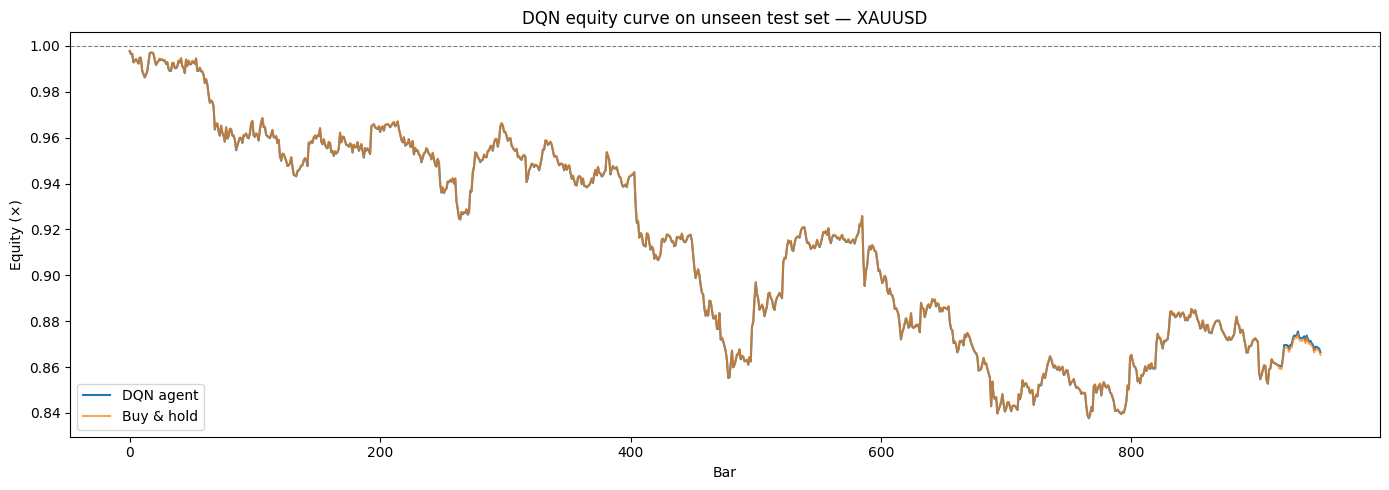

In [ ]:
# ── RL: evaluate the learned policy on the unseen test set ───────────────────
import matplotlib.pyplot as plt

def run_policy(net, states, batch=4096):
    """Greedy roll-out. Position is part of the state, so this is sequential
    across time but batched across the network call for each step."""
    n = len(states)
    positions = np.zeros(n, dtype=np.float32)
    pos = 0.0
    # Precompute nothing path-independent; step through time.
    for i in range(n):
        s = states[i:i + 1]
        q = net([s, np.array([[pos]], dtype=np.float32)], training=False).numpy()[0]
        pos = float(ACTION_TO_POS[int(q.argmax())])
        positions[i] = pos
    return positions

positions = run_policy(online_net, RL_STATES_TEST)

# Convert positions -> signal codes for the shared back-test (1=long, 2=short, 0=flat)
rl_pred = np.where(positions == 1, 1, np.where(positions == -1, 2, 0)).astype(int)

res_rl = backtest_signals(rl_pred, RL_PRICES_TEST, proba=None, conf_threshold=0.0)
print("── DQN agent on unseen test set ─────────────────────────────")
print(f"  Total return : {res_rl['total_return_pct']:+.2f}%")
print(f"  Buy & hold   : {res_rl['buy_hold_pct']:+.2f}%")
print(f"  Win rate     : {res_rl['win_rate_pct']:.2f}%")
print(f"  # trades     : {res_rl['n_trades']}")
print(f"  Sharpe       : {res_rl['sharpe']:.2f}")
print(f"  Max drawdown : {res_rl['max_drawdown_pct']:.2f}%")

# Position distribution sanity check
vals, cnts = np.unique(rl_pred, return_counts=True)
name = {0: "flat", 1: "long", 2: "short"}
print("\nAction distribution:", {name[int(v)]: int(c) for v, c in zip(vals, cnts)})

plt.figure(figsize=(14, 5))
plt.plot(res_rl["equity"],    label="DQN agent")
plt.plot(res_rl["bh_equity"], label="Buy & hold", alpha=0.7)
plt.axhline(1.0, color="gray", ls="--", lw=0.8)
plt.title("DQN equity curve on unseen test set — XAUUSD")
plt.xlabel("Bar"); plt.ylabel("Equity (×)"); plt.legend()
plt.tight_layout(); plt.show()


## 🔧 Fixing slow tuning & poor accuracy (do these next)

**1. Make features stationary — this is usually the #1 accuracy fix.**
Raw price *levels* drift, so the scaler fit on train produces out-of-range values on test.
Replace absolute OHLC with **relative/return features** *before* windowing, e.g.:
```python
for c in ['open','high','low','close','open_4h','high_4h','low_4h','close_4h',
          'open_1d','high_1d','low_1d','close_1d']:
    df[c] = np.log(df[c] / df['close'].shift(1))   # log-return vs previous close
df['volume'] = df['volume'].pct_change()
```
Then rebuild `df_train`/`df_test`, re-scale, and re-window. Both the LSTM and the DQN benefit.

**2. Make Keras-Tuner ~5–10× faster:**
- `hyperband_iterations=1`, `max_epochs=20` (was 2 / 40).
- Or swap to `kt.BayesianOptimization(..., max_trials=25)` — far fewer fits.
- Wrap training data in `tf.data`: `tf.data.Dataset.from_tensor_slices((X,y)).cache().shuffle(10000).batch(512).prefetch(tf.data.AUTOTUNE)`.
- Keep `recurrent_dropout=0` (already set) so the fast cuDNN LSTM kernel is used.

**3. Fill the GPU (single T4, 15 GB):** raise `N_ENVS`/`BATCH_SIZE` until GPU-RAM is ~80% full.
Multiple GPUs would use `tf.distribute.MirroredStrategy`, but you have one GPU, so big batches + XLA + mixed precision is the right lever.

**4. Trust the back-test, not accuracy.** A model can have low class accuracy yet be profitable if it's right on the *big* moves — always confirm with the equity curve / Sharpe above.
